# Import package

In [1]:
from typing import List, Dict
import torch

import sys 
sys.path.append(".")
sys.path.append("..")

from pipeline_attend_and_excite import AttendAndExcitePipeline
from config import RunConfig
from run import run_on_prompt, get_indices_to_alter
from utils import vis_utils
from utils.ptp_utils import AttentionStore

%load_ext autoreload 
%autoreload 2

# Load Model Weights (may take a few minutes)

In [2]:
NUM_DIFFUSION_STEPS = 50
GUIDANCE_SCALE = 7.5
MAX_NUM_WORDS = 77
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
stable = AttendAndExcitePipeline.from_pretrained("CompVis/stable-diffusion-v1-4").to(device)
tokenizer = stable.tokenizer

d:\MiniConda3\envs\ldm\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

vae\diffusion_pytorch_model.safetensors not found


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

d:\MiniConda3\envs\ldm\lib\site-packages\diffusers\models\modeling_utils.py:101: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(checkpoint_file, map_locatio

# Pipeline Wrapper

In [4]:
# configurable parameters (see RunConfig for all parameters)
# scale factor- intensity of shift by gradient
# thresholds- a dictionary for iterative refinement mapping the iteration number to the attention threshold
# max_iter_to_alter- maximal inference timestep to apply Attend-and-Excite
def run_and_display(prompts: List[str],
                    controller: AttentionStore,
                    indices_to_alter: List[int],
                    generator: torch.Generator,
                    run_standard_sd: bool = False,
                    scale_factor: int = 20,
                    thresholds: Dict[int, float] = {0: 0.05, 10: 0.5, 20: 0.8},
                    max_iter_to_alter: int = 25,
                    display_output: bool = False):
    config = RunConfig(prompt=prompts[0],
                       run_standard_sd=run_standard_sd,
                       scale_factor=scale_factor,
                       thresholds=thresholds,
                       max_iter_to_alter=max_iter_to_alter)
    image = run_on_prompt(model=stable,
                          prompt=prompts,
                          controller=controller,
                          token_indices=indices_to_alter,
                          seed=generator,
                          config=config)
    if display_output:
        display(image)
    return image

# Show Cross-Attention Per Strengthened Token

## Define your seeds, prompt and the indices to strengthen

In [ ]:
# helper cell to run all below cells without having to re-run the above cell

In [21]:
prompt = "an elephant with a crown"
seeds = [21]

In [22]:
token_indices = get_indices_to_alter(stable, prompt)

{1: 'an', 2: 'elephant', 3: 'with', 4: 'a', 5: 'crown'}
Altering tokens: ['elephant', 'crown']


## Stable Diffusion

In [ ]:
for seed in seeds:
    g = torch.Generator('cpu').manual_seed(seed)
    stable.to("cpu")
    prompts = [prompt]
    controller = AttentionStore()
    image = run_and_display(prompts=prompts,
                            controller=controller,
                            indices_to_alter=token_indices,
                            generator=g,
                            run_standard_sd=True,
                            display_output=True)
    vis_utils.show_cross_attention(attention_store=controller,
                                    prompt=prompt,
                                    tokenizer=tokenizer,
                                    res=16,
                                    from_where=("up", "down", "mid"),
                                    indices_to_alter=token_indices,
                                    orig_image=image)

## Attend-and-Excite

  0%|          | 0/50 [00:00<?, ?it/s]

Iteration 0 | Loss: 0.2838
Iteration 1 | Loss: 0.0005
Iteration 2 | Loss: 0.0005
Iteration 3 | Loss: 0.0005
Iteration 4 | Loss: 0.0007
Iteration 5 | Loss: 0.0007
Iteration 6 | Loss: 0.0008
Iteration 7 | Loss: 0.0009
Iteration 8 | Loss: 0.0010
Iteration 9 | Loss: 0.0011
Iteration 10 | Loss: 0.0020
Iteration 11 | Loss: 0.0023
Iteration 12 | Loss: 0.0047
Iteration 13 | Loss: 0.0074
Iteration 14 | Loss: 0.0116
Iteration 15 | Loss: 0.0234
Iteration 16 | Loss: 0.0322
Iteration 17 | Loss: 0.0214
Iteration 18 | Loss: 0.1339
Iteration 19 | Loss: 0.0161
Iteration 20 | Loss: 0.0351
Iteration 21 | Loss: 0.0390
Iteration 22 | Loss: 0.0547
Iteration 23 | Loss: 0.0631
Iteration 24 | Loss: 0.0599


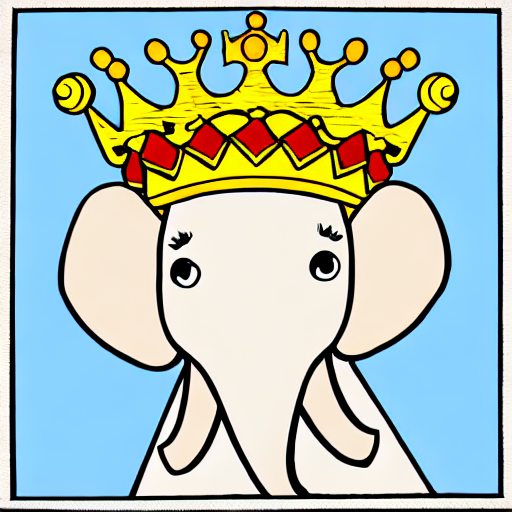

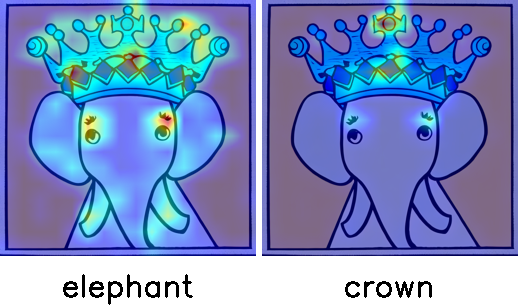

In [24]:
for seed in seeds:
    g = torch.Generator('cpu').manual_seed(seed)
    stable.to("cpu")
    prompts = [prompt]
    controller = AttentionStore()
    image = run_and_display(prompts=prompts,
                            controller=controller,
                            indices_to_alter=token_indices,
                            generator=g,
                            run_standard_sd=False,
                            display_output=True)
    vis_utils.show_cross_attention(attention_store=controller,
                                   prompt=prompt,
                                   tokenizer=tokenizer,
                                   res=16,
                                   from_where=("up", "down", "mid"),
                                   indices_to_alter=token_indices,
                                   orig_image=image)